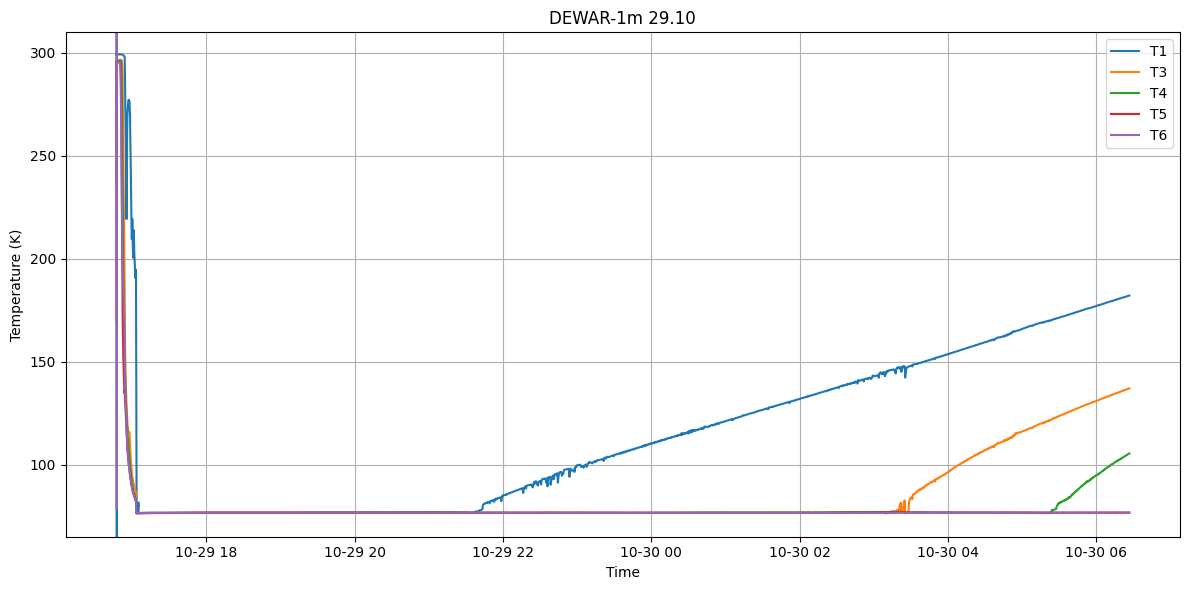

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Ruta del archivo
file_path = "/eos/user/j/jcapotor/FBGdata/Data/Dewar1m/20251029/temperatures_1.txt"

# Leer el archivo
# Está separado por tabulaciones ('\t'), sin encabezados
df = pd.read_csv(file_path, sep='\t', header=None)

# Combinar fecha y hora
df['Datetime'] = pd.to_datetime(df[0] + ' ' + df[1], format='%m/%d/%Y %I:%M:%S %p')

# Renombrar columnas para facilitar el acceso
df.columns = ['Date', 'Time', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'Datetime']

# Establecer datetime como índice si quieres
# df.set_index('Datetime', inplace=True)

# Graficar una o varias columnas
plt.figure(figsize=(12, 6))
plt.plot(df['Datetime'], df['T1'], label='T1')
#plt.plot(df['Datetime'], df['T2'], label='T2')
plt.plot(df['Datetime'], df['T3'], label='T3')
plt.plot(df['Datetime'], df['T4'], label='T4')
plt.plot(df['Datetime'], df['T5'], label='T5')
plt.plot(df['Datetime'], df['T6'], label='T6')

plt.xlabel('Time')
plt.ylabel('Temperature (K)')
plt.ylim(65, 310)
#plt.xlim(pd.to_datetime('2025-06-12 15:09:45'), pd.to_datetime('2025-06-12 20:10:00'))
plt.title('DEWAR-1m 29.10')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
import re

# Ruta del archivo
file_path = "/eos/user/j/jcapotor/FBGdata/Data/Dewar1m/20251029/peaks_1.txt"

timestamps = []
peaks = []

# Expresión regular para capturar números en notación científica
sci_num_pattern = re.compile(r"[+-]?\d+\.\d+E[+-]?\d+")

with open(file_path, "r") as file:
    for line in file:
        # Saltar líneas vacías
        if not line.strip():
            continue

        # Separar la fecha y hora (primeros dos campos)
        parts = line.split("\t")
        if len(parts) < 2:
            continue

        timestamp = parts[0] + " " + parts[1]
        timestamps.append(timestamp)

        # Extraer todos los números en formato científico
        values = sci_num_pattern.findall(line)

        # Los 10 últimos valores son los relevantes (5 λB + 5 amplitudes)
        # Si tu archivo tiene más sensores, ajusta este número
        peaks.append(values[-10:])

# Crear DataFrame
columns = ["λB1_m", "amp1", "λB2_m", "amp2", "λB3_m", "amp3", "λB4_m", "amp4", "λB5_m", "amp5"]
df = pd.DataFrame(peaks, columns=columns)
df.insert(0, "timestamp", timestamps)

# Convertir tipos numéricos
for col in columns:
    df[col] = df[col].astype(float)

# Añadir columnas en nanómetros
for i in range(1, 10, 2):  # columnas λB1_m, λB2_m...
    nm_col = df.columns[i] + "_nm"
    df[nm_col] = df.iloc[:, i].astype(float) * 1e9

# Mostrar resumen
print(df.head())
print(df.info())


                                         timestamp     λB1_m      amp1  \
0  29-Oct-2025 16:49:32.709431 3970741772709431323  0.000002  0.003415   
1  29-Oct-2025 16:49:32.713431 3970741772713431327  0.000002  0.003415   
2  29-Oct-2025 16:49:32.717431 3970741772717431331  0.000002  0.003415   
3  29-Oct-2025 16:49:32.721431 3970741772721431334  0.000002  0.003415   
4  29-Oct-2025 16:49:32.725431 3970741772725431338  0.000002  0.003415   

      λB2_m      amp2     λB3_m    amp3     λB4_m      amp4  λB5_m  amp5  \
0  0.000002  0.003308  0.000002  0.0032  0.000002  0.003093    0.0   0.0   
1  0.000002  0.003308  0.000002  0.0032  0.000002  0.003093    0.0   0.0   
2  0.000002  0.003307  0.000002  0.0032  0.000002  0.003093    0.0   0.0   
3  0.000002  0.003307  0.000002  0.0032  0.000002  0.003093    0.0   0.0   
4  0.000002  0.003307  0.000002  0.0032  0.000002  0.003093    0.0   0.0   

      λB1_m_nm     λB2_m_nm     λB3_m_nm     λB4_m_nm  λB5_m_nm  
0  1546.119208  1551.866521  155


✅ DataFrame limpio y estructurado:
                   timestamp       λB1_nm       λB2_nm       λB3_nm  \
0 2025-10-29 16:49:32.709431  1546.119208  1551.866521  1557.681506   
1 2025-10-29 16:49:32.713431  1546.118512  1551.867436  1557.684417   
2 2025-10-29 16:49:32.717431  1546.125906   1551.87337  1557.688554   
3 2025-10-29 16:49:32.721431  1546.123807  1551.872867  1557.689923   
4 2025-10-29 16:49:32.725431  1546.130986  1551.878544  1557.693605   

        λB4_nm λB5_nm  
0  1563.489165    0.0  
1  1563.485666    0.0  
2  1563.495335    0.0  
3   1563.49089    0.0  
4  1563.500389    0.0  

Columnas: ['timestamp', 'λB1_nm', 'λB2_nm', 'λB3_nm', 'λB4_nm', 'λB5_nm']


<Axes: title={'center': 'FBG DW-2 - λB (nm) vs time'}, xlabel='timestamp'>

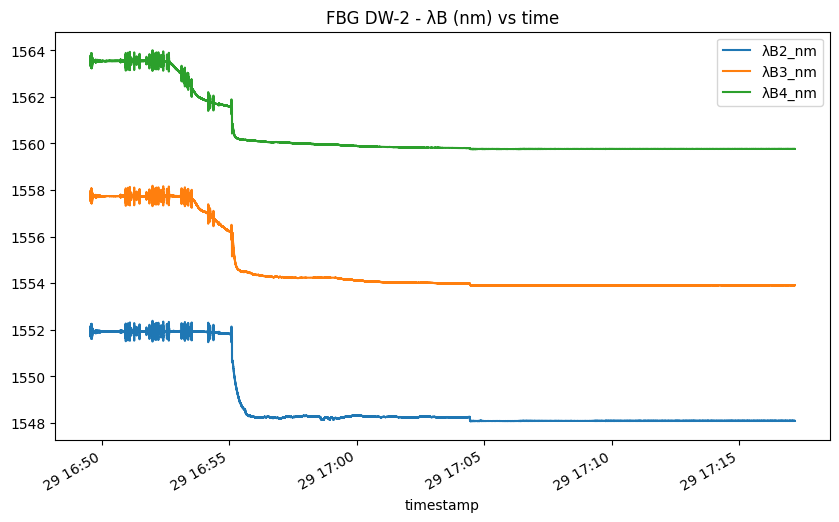

In [11]:
import pandas as pd
import re

# Ruta del archivo
file_path = "/eos/user/j/jcapotor/FBGdata/Data/Dewar1m/20251029/peaks_1.txt"

timestamps = []
peaks = []

# Expresión regular para capturar números en notación científica
sci_num_pattern = re.compile(r"[+-]?\d+\.\d+E[+-]?\d+")

# --- Lectura del archivo ---
with open(file_path, "r") as file:
    for line in file:
        if not line.strip():
            continue

        parts = line.split("\t")

        # El timestamp real está solo en la PRIMERA columna
        timestamp = parts[0].strip()
        timestamps.append(timestamp)

        # Buscar todos los números en notación científica
        values = sci_num_pattern.findall(line)

        # Los últimos 10 valores son las 5 λB y 5 amplitudes
        peaks.append(values[-10:])

# --- Construcción del DataFrame ---
columns = ["λB1_m", "amp1", "λB2_m", "amp2", "λB3_m", "amp3", "λB4_m", "amp4", "λB5_m", "amp5"]
df = pd.DataFrame(peaks, columns=columns)
df.insert(0, "timestamp", timestamps)

# Convertir longitudes a float y luego a nanómetros
for i in range(1, 10, 2):  # columnas 1,3,5,7,9 → λB
    df.iloc[:, i] = df.iloc[:, i].astype(float)
    nm_col = f"λB{(i+1)//2}_nm"
    df[nm_col] = df.iloc[:, i] * 1e9

# --- Filtrar solo las columnas deseadas ---
df_filtered = df[["timestamp", "λB1_nm", "λB2_nm", "λB3_nm", "λB4_nm", "λB5_nm"]].copy()

# --- Convertir timestamp a formato datetime ---
df_filtered["timestamp"] = df_filtered["timestamp"].str.extract(
    r"^(\d{2}-[A-Za-z]{3}-\d{4} \d{2}:\d{2}:\d{2}\.\d+)"
)
df_filtered["timestamp"] = pd.to_datetime(df_filtered["timestamp"], format="%d-%b-%Y %H:%M:%S.%f")

# --- Mostrar resultado ---
print("\n✅ DataFrame limpio y estructurado:")
print(df_filtered.head())
print("\nColumnas:", df_filtered.columns.tolist())

# --- (Opcional) Guardar a CSV limpio ---
#df_filtered.to_csv("/eos/user/j/jcapotor/FBGdata/Data/Dewar1m/20251029/peaks_clean.csv", index=False)

# --- (Opcional) Graficar ---
#df_filtered.plot(x="timestamp", y=["λB1_nm","λB2_nm","λB3_nm","λB4_nm","λB5_nm"], figsize=(10,6), title="FBG DW-2 - λB (nm) vs time")
df_filtered.plot(x="timestamp", y=["λB2_nm","λB3_nm","λB4_nm"], figsize=(10,6), title="FBG DW-2 - λB (nm) vs time")

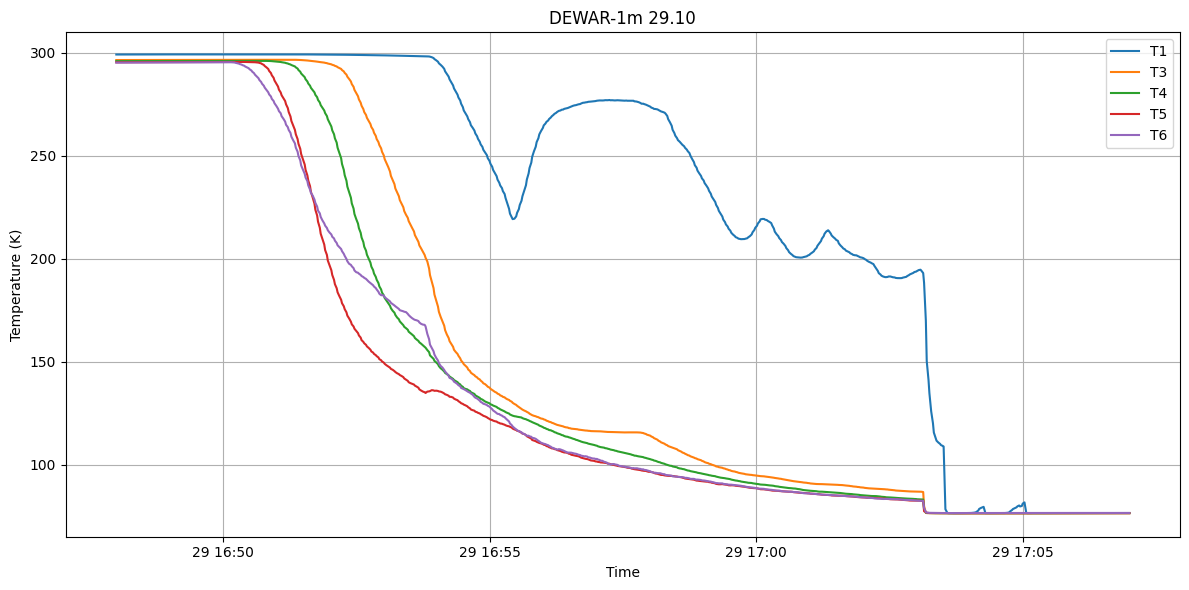

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Ruta del archivo
file_path = "/eos/user/j/jcapotor/FBGdata/Data/Dewar1m/20251029/temperatures_1.txt"

# Leer el archivo (separado por tabulaciones)
df = pd.read_csv(file_path, sep='\t', header=None)

# Combinar fecha y hora
df['Datetime'] = pd.to_datetime(df[0] + ' ' + df[1], format='%m/%d/%Y %I:%M:%S %p')

# Renombrar columnas
df.columns = ['Date', 'Time', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'Datetime']

# --- 🔹 Filtrar desde el inicio hasta las 17:15 ---
# Asegúrate de usar el mismo día que tus datos (aquí 29-Oct-2025)
#fecha_inicio = df['Datetime'].min().normalize()  # inicio del día
fecha_inicio = pd.to_datetime("2025-10-29 16:48:00")
fecha_fin = pd.to_datetime("2025-10-29 17:07:00")

df_filtrado = df[(df['Datetime'] >= fecha_inicio) & (df['Datetime'] <= fecha_fin)]

# --- 🔹 Graficar los datos filtrados ---
plt.figure(figsize=(12, 6))
plt.plot(df_filtrado['Datetime'], df_filtrado['T1'], label='T1')
plt.plot(df_filtrado['Datetime'], df_filtrado['T3'], label='T3')
plt.plot(df_filtrado['Datetime'], df_filtrado['T4'], label='T4')
plt.plot(df_filtrado['Datetime'], df_filtrado['T5'], label='T5')
plt.plot(df_filtrado['Datetime'], df_filtrado['T6'], label='T6')

plt.xlabel('Time')
plt.ylabel('Temperature (K)')
plt.ylim(65, 310)
plt.title('DEWAR-1m 29.10')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


✅ DataFrame combinado (λB + Temperaturas):
                                 λB1_nm       λB2_nm       λB3_nm  \
timestamp                                                           
2025-10-29 16:49:32.709431  1546.119208  1551.866521  1557.681506   
2025-10-29 16:49:32.713431  1546.118512  1551.867436  1557.684417   
2025-10-29 16:49:32.717431  1546.125906   1551.87337  1557.688554   
2025-10-29 16:49:32.721431  1546.123807  1551.872867  1557.689923   
2025-10-29 16:49:32.725431  1546.130986  1551.878544  1557.693605   

                                 λB4_nm λB5_nm        Date        Time  \
timestamp                                                                
2025-10-29 16:49:32.709431  1563.489165    0.0  10/29/2025  4:49:32 PM   
2025-10-29 16:49:32.713431  1563.485666    0.0  10/29/2025  4:49:32 PM   
2025-10-29 16:49:32.717431  1563.495335    0.0  10/29/2025  4:49:32 PM   
2025-10-29 16:49:32.721431   1563.49089    0.0  10/29/2025  4:49:32 PM   
2025-10-29 16:49:32.725431  1

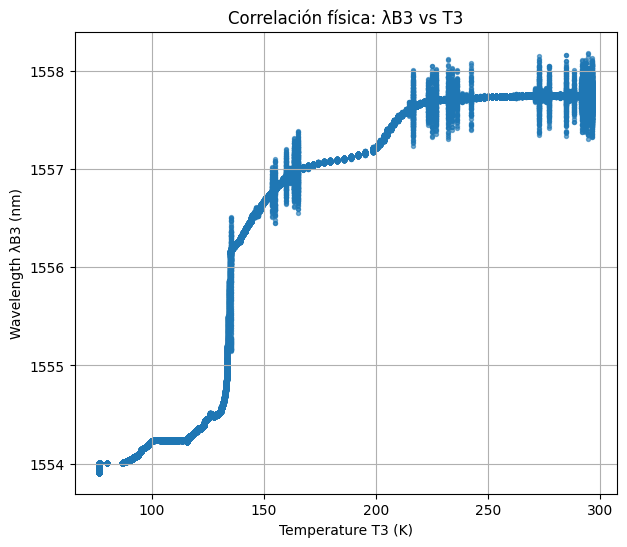

📈 λB3–T3 = 0.96500


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 🔹 Cargar FBG (peaks) ---
file_fbg = "/eos/user/j/jcapotor/FBGdata/Data/Dewar1m/20251029/peaks_1.txt"

import re
timestamps = []
peaks = []

sci_num_pattern = re.compile(r"[+-]?\d+\.\d+E[+-]?\d+")

with open(file_fbg, "r") as file:
    for line in file:
        if not line.strip():
            continue

        parts = line.split("\t")
        timestamp = parts[0].strip()
        timestamps.append(timestamp)

        values = sci_num_pattern.findall(line)
        peaks.append(values[-10:])  # λB1..5 y amplitudes

columns = ["λB1_m", "amp1", "λB2_m", "amp2", "λB3_m", "amp3", "λB4_m", "amp4", "λB5_m", "amp5"]
df_fbg = pd.DataFrame(peaks, columns=columns)
df_fbg.insert(0, "timestamp", timestamps)

# Convertir longitudes a float y luego a nanómetros
for i in range(1, 10, 2):
    df_fbg.iloc[:, i] = df_fbg.iloc[:, i].astype(float)
    nm_col = f"λB{(i+1)//2}_nm"
    df_fbg[nm_col] = df_fbg.iloc[:, i] * 1e9

# Extraer timestamp en formato legible
df_fbg["timestamp"] = df_fbg["timestamp"].str.extract(
    r"^(\d{2}-[A-Za-z]{3}-\d{4} \d{2}:\d{2}:\d{2}\.\d+)"
)
df_fbg["timestamp"] = pd.to_datetime(df_fbg["timestamp"], format="%d-%b-%Y %H:%M:%S.%f")

df_fbg = df_fbg[["timestamp", "λB1_nm", "λB2_nm", "λB3_nm", "λB4_nm", "λB5_nm"]].set_index("timestamp")

# --- 🔹 Cargar temperaturas ---
file_temp = "/eos/user/j/jcapotor/FBGdata/Data/Dewar1m/20251029/temperatures_1.txt"

df_temp = pd.read_csv(file_temp, sep='\t', header=None)
df_temp['Datetime'] = pd.to_datetime(df_temp[0] + ' ' + df_temp[1], format='%m/%d/%Y %I:%M:%S %p')
df_temp.columns = ['Date', 'Time', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'Datetime']
df_temp = df_temp.set_index("Datetime")

# Convertir a numéricos por seguridad
for c in ['T1','T2','T3','T4','T5','T6']:
    df_temp[c] = pd.to_numeric(df_temp[c], errors='coerce')

# --- 🔹 Emparejar temporalmente (nearest match) ---
matched = pd.merge_asof(
    df_fbg.sort_index(),
    df_temp.sort_index(),
    left_index=True,
    right_index=True,
    direction="nearest",
    tolerance=pd.Timedelta("2s")  # tolerancia de ±2 segundos
)

print("✅ DataFrame combinado (λB + Temperaturas):")
print(matched.head())

# --- 🔹 Graficar correlación λB vs T ---
plt.figure(figsize=(7,6))
plt.scatter(matched["T3"], matched["λB3_nm"], s=8, alpha=0.6)
plt.xlabel("Temperature T3 (K)")
plt.ylabel("Wavelength λB3 (nm)")
plt.title("Correlación física: λB3 vs T3")
plt.grid(True)
plt.show()

# --- 🔹 Calcular correlación numérica (opcional) ---
corr = matched["T3"].corr(matched["λB3_nm"])
print(f"📈 λB3–T3 = {corr:.5f}")


📈 Pendiente dλ/dT = 0.01893 nm/K
Intercepto = 1552.45937 nm
R² del ajuste = 0.93122


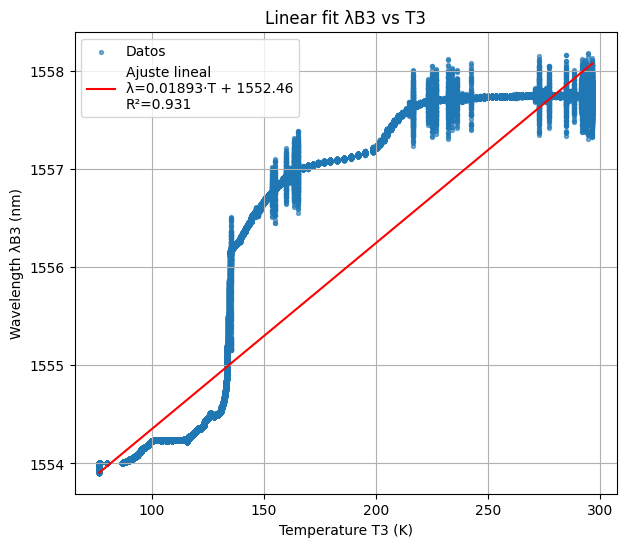

In [27]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Seleccionamos los datos para un sensor específico, por ejemplo λB3 vs T3
X = matched["T3"].values.reshape(-1, 1)  # Temperatura (K)
y = matched["λB3_nm"].values  # Longitud de onda (nm)

# --- Ajuste lineal ---
model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]      # Pendiente dλ/dT
intercept = model.intercept_ # Intercepto
r2 = model.score(X, y)       # Coeficiente de determinación

print(f"📈 Pendiente dλ/dT = {slope:.5f} nm/K")
print(f"Intercepto = {intercept:.5f} nm")
print(f"R² del ajuste = {r2:.5f}")

# --- Graficar con línea de ajuste ---
plt.figure(figsize=(7,6))
plt.scatter(X, y, s=8, alpha=0.6, label='Datos')
plt.plot(X, model.predict(X), color='red', label=f'Ajuste lineal\nλ={slope:.5f}·T + {intercept:.2f}\nR²={r2:.3f}')
plt.xlabel("Temperature T3 (K)")
plt.ylabel("Wavelength λB3 (nm)")
plt.title("Linear fit λB3 vs T3")
plt.legend()
plt.grid(True)
plt.show()


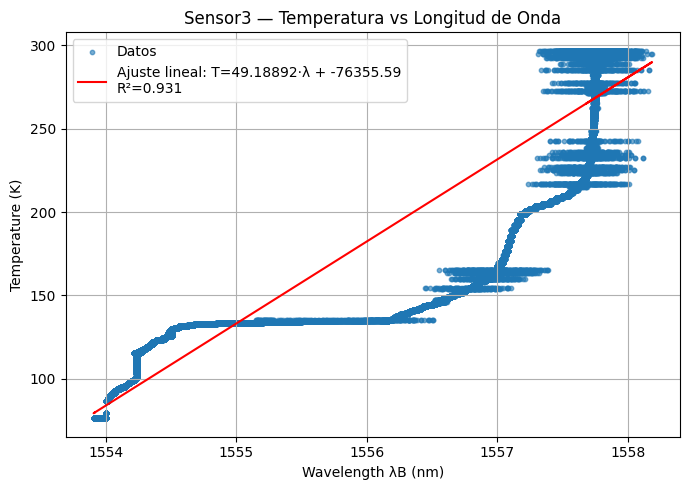

Sensor3: dT/dλ = 49.18892 K/nm, R² = 0.93122


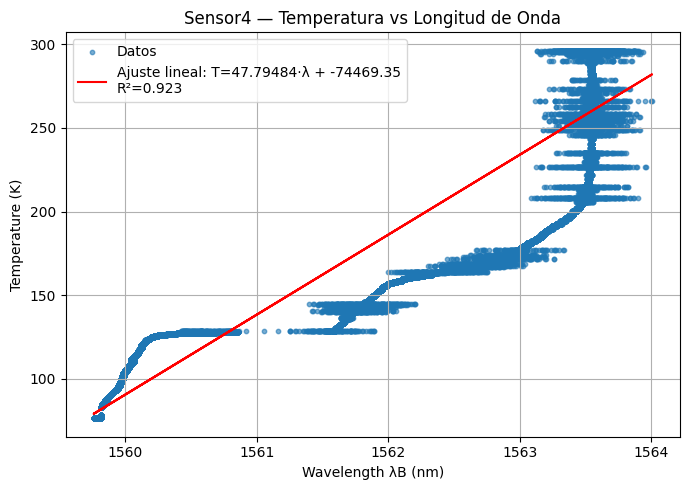

Sensor4: dT/dλ = 47.79484 K/nm, R² = 0.92317


In [32]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sensores a graficar por separado
sensors = {
    "Sensor3": ("λB3_nm", "T3"),
    "Sensor4": ("λB4_nm", "T4")
}

for name, (L_col, T_col) in sensors.items():
    X = matched[L_col].values.reshape(-1,1)  # λB → eje X
    y = matched[T_col].values                 # Temperatura → eje Y

    # Ajuste lineal
    model = LinearRegression()
    model.fit(X, y)
    y_fit = model.predict(X)

    slope = model.coef_[0]       # dT/dλ
    intercept = model.intercept_
    r2 = model.score(X, y)

    # Graficar
    plt.figure(figsize=(7,5))
    plt.scatter(X, y, s=10, alpha=0.6, label='Datos')
    plt.plot(X, y_fit, color='red', label=f'Ajuste lineal: T={slope:.5f}·λ + {intercept:.2f}\nR²={r2:.3f}')
    plt.xlabel("Wavelength λB (nm)")
    plt.ylabel("Temperature (K)")
    plt.title(f"{name} — Temperatura vs Longitud de Onda")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"{name}: dT/dλ = {slope:.5f} K/nm, R² = {r2:.5f}")
